In [376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygments.lexers import factor

In [377]:
# ── Change this one variable to switch between algorithms ──────────────────
# Options: "lasso", "xgboost", "xgboost_expanding",
#          "xgboost_factor_screened", "lgbm_factor_screened",
#          "lasso_factor_screened", "xgboost_rank_normalized",
#          "xgboost_enhanced", "benchmark", "factor"
ALGO = "xgboost_expanding_ab"

BACKTEST_DIR = f"../data/backtest/{ALGO}"

In [378]:
data = pd.read_parquet('../data/processed/data.parquet')

In [379]:
data = data.sort_values(by=['eom', 'id'], ascending = True)

In [380]:
data['ret'].min()

np.float64(-0.999993846)

In [381]:
for col in data.columns.to_list():
    print(col)

id
date
eom
source_crsp
size_grp
obs_main
exch_main
primary_sec
gvkey
iid
permno
permco
excntry
curcd
fx
common
comp_tpci
crsp_shrcd
comp_exchg
crsp_exchcd
adjfct
shares
me_lag1
gics
sic
naics
ff49
me_company
prc
prc_local
dolvol
ret
ret_lag_dif
ret_exc_lead1m
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
div1m_me
div3m_me
div6m_me
div12m_me
divspc1m_me
divspc12m_me
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
ret_18_1
ret_24_1
ret_24_12
ret_36_1
ret_36_12
ret_48_12
ret_48_1
ret_60_1
ret_60_12
ret_60_36
seas_1_1an
seas_1_1na
seas_2_5an
seas_2_5na
seas_6_10an
seas_6_10na
seas_11_15an
seas_11_15na
seas_16_20an
seas_16_20na
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
pstk_gr1
debt_gr1
sale_gr1
cogs_gr1
sga_gr1
opex_gr1
capx_gr1
inv_gr1
at_gr3
ca_gr3
nca_gr3
lt_gr3
cl_gr3
ncl_gr3
be_gr3
pstk_gr3
debt_gr3
sale_gr3
cogs_gr3
sga

In [382]:
len(data.columns)

438

In [383]:
port = pd.read_csv(f'{BACKTEST_DIR}/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100708301,long,0.002827,0.010052,0.158037,1986-01-31
1,100706701,long,0.002039,0.010052,0.020885,1986-01-31
2,100706501,long,0.004502,0.010052,0.043091,1986-01-31
3,100706301,long,0.004502,0.010052,0.125457,1986-01-31
4,100704001,long,0.004502,0.010052,0.015205,1986-01-31
...,...,...,...,...,...,...
139755,106555601,short,-0.019271,0.004800,-0.046022,2008-12-31
139756,116054101,short,-0.001676,0.004806,-0.175528,2008-12-31
139757,100172201,short,-0.019405,0.004806,-0.050318,2008-12-31
139758,102860801,short,-0.004727,0.004808,-0.206690,2008-12-31


In [384]:
algo_ret = pd.read_csv(f'{BACKTEST_DIR}/monthly_returns.csv')
algo_ret

,eom,ic_pearson,ic_spearman,best_iteration,n_train,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe,gross_exposure
0,1986-01-31,0.097281,0.111541,1,149779,1986,1985,0.087075,0.034272,0.052804,0.050804,1.000000,169,169,1692,2.0
1,1986-02-28,0.080846,0.087415,1,149779,1986,1985,0.049999,0.039813,0.010186,0.008092,1.046939,169,169,1698,2.0
2,1986-03-31,-0.023785,-0.017649,1,149779,1986,1985,-0.004431,0.015472,-0.019904,-0.022049,1.072545,174,174,1745,2.0
3,1986-04-30,0.036596,0.030829,1,149779,1986,1985,0.025148,0.040843,-0.015695,-0.017373,0.839331,175,175,1756,2.0
4,1986-05-31,0.078104,0.087774,1,149779,1986,1985,-0.003517,-0.027535,0.024018,0.022083,0.967225,176,176,1765,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2008-08-31,-0.068184,-0.074627,17,1129984,2008,2007,-0.137146,-0.075111,-0.062035,-0.063650,0.807500,240,240,2404,2.0
272,2008-09-30,-0.127373,-0.102219,17,1129984,2008,2007,-0.308633,-0.244006,-0.064626,-0.066709,1.041301,234,234,2345,2.0
273,2008-10-31,-0.146408,-0.114832,17,1129984,2008,2007,-0.160200,-0.130172,-0.030028,-0.032562,1.266935,215,215,2152,2.0
274,2008-11-30,0.225023,0.198562,17,1129984,2008,2007,0.136176,0.022764,0.113412,0.110736,1.338024,200,200,2006,2.0


In [385]:
idx = np.where(algo_ret['net_qspread'] == algo_ret['net_qspread'].max())
idx

(array([169]),)

<Axes: >

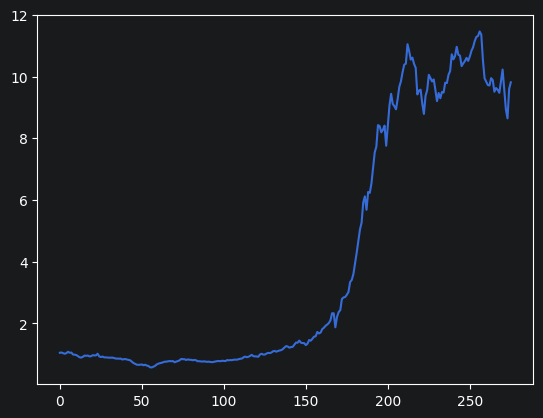

In [386]:
(1 + algo_ret['net_qspread']).cumprod().plot()

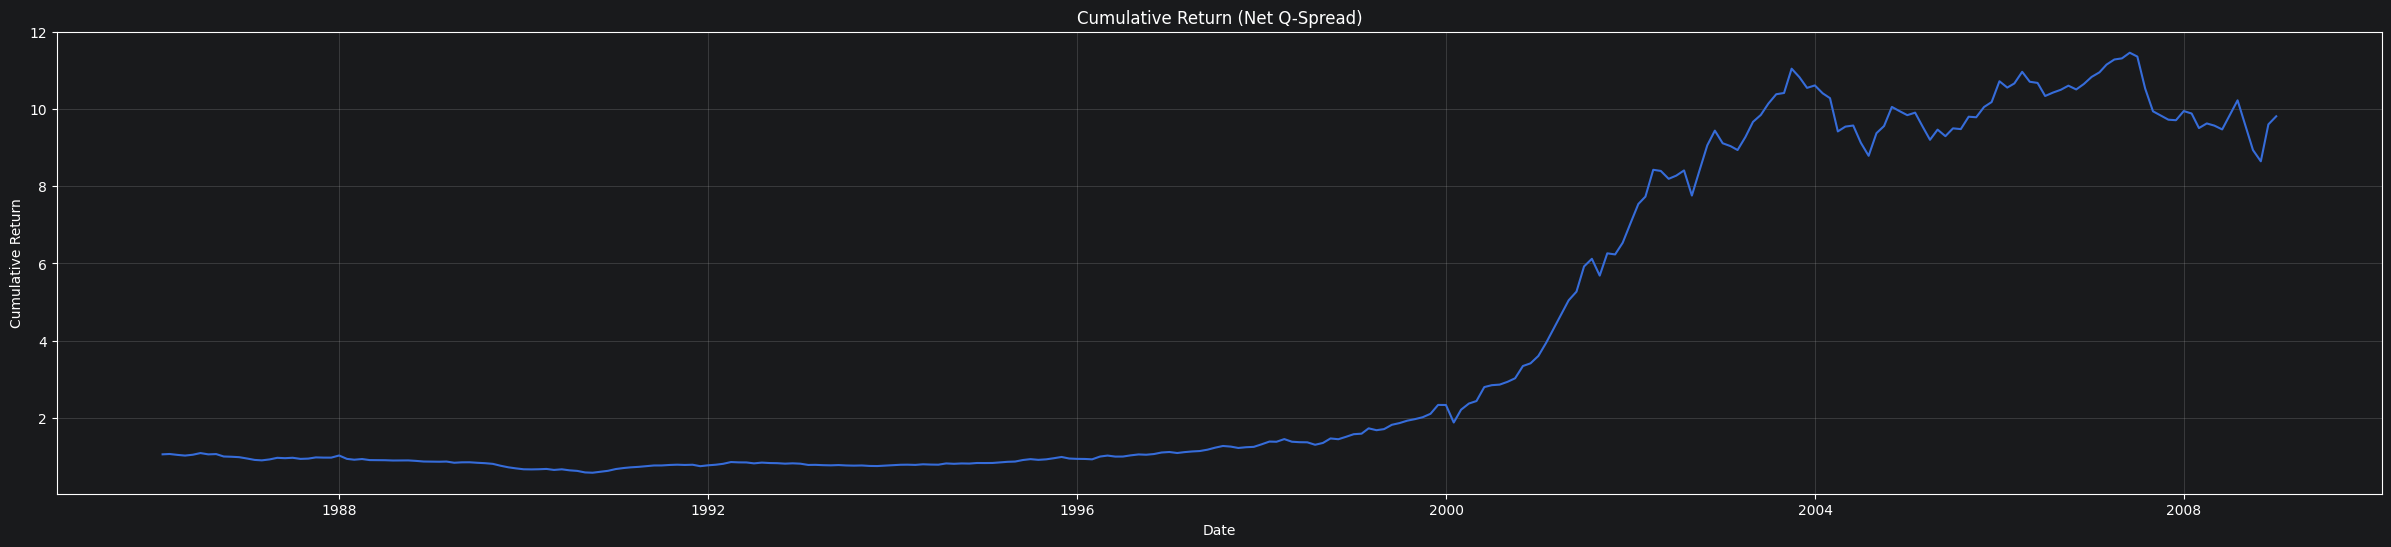

In [387]:
# Ensure datetime
algo_ret['eom'] = pd.to_datetime(algo_ret['eom'])

# Sort by date
xg_boost_ret = algo_ret.sort_values('eom')

# Cumulative return
series = (1 + algo_ret['net_qspread']).cumprod()

# Plot (wider figure)
plt.figure(figsize=(30, 6))
plt.plot(algo_ret['eom'], series)

plt.title('Cumulative Return (Net Q-Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.show()

In [388]:
factor_df = pd.read_csv(f'{BACKTEST_DIR}/feature_importance.csv', on_bad_lines="skip")
factor_df

,Unnamed: 0,me_company,prc,prc_local,dolvol,ret,enterprise_value,book_equity,assets,sales,...,dstnetis_mev,dbnetis_mev,netis_mev,fincf_mev,eq_dur,mispricing_mgmt,mispricing_perf,age,qmj_prof,qmj_safety
0,1986-01-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
1,1986-02-28,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
2,1986-03-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
3,1986-04-30,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
4,1986-05-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
5,1986-06-30,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
6,1986-07-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
7,1986-08-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
8,1986-09-30,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421
9,1986-10-31,0.008035,0.007011,0.00973,0.008816,0.014113,0.008482,0.006341,0.004342,0.004422,...,0.011598,0.0,0.0,0.0,0.017848,0.0,0.009019,0.006296,0.006136,0.01421


In [389]:
for factor in factor_df:
    print(factor)

Unnamed: 0
me_company
prc
prc_local
dolvol
ret
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
seas_1_1an
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
debt_gr1
sale_gr1
cogs_gr1
opex_gr1
capx_gr1
inv_gr1
cash_gr1a
inv_gr1a
rec_gr1a
ppeg_gr1a
lti_gr1a
debtst_gr1a
ap_gr1a
txp_gr1a
debtlt_gr1a
txditc_gr1a
coa_gr1a
col_gr1a
cowc_gr1a
ncoa_gr1a
ncol_gr1a
nncoa_gr1a
oa_gr1a
ol_gr1a
fna_gr1a
fnl_gr1a
nfna_gr1a
gp_gr1a
ebitda_gr1a
ebit_gr1a
ope_gr1a
ni_gr1a
nix_gr1a
dp_gr1a
fincf_gr1a
ocf_gr1a
fcf_gr1a
nwc_gr1a
eqnetis_gr1a
dltnetis_gr1a
dbnetis_gr1a
netis_gr1a
eqnpo_gr1a
tax_gr1a
eqbb_gr1a
eqis_gr1a
div_gr1a
eqpo_gr1a
capx_gr1a
be_gr1a
capx_at
spi_at
xido_at
nri_at
gp_sale
ebitda_sale
ebit_sale
pi_sale
ni_sale
nix_sale
ocf_sale
fcf_sale
gp_at
ebitda_at
ebit_at
fi_at
cop_at
ni_at
ope_be
n

In [390]:
algo_ret['net_qspread'].max()

np.float64(0.1770806908305673)

In [391]:
idx = np.where(algo_ret['net_qspread'] == algo_ret['net_qspread'].max())

In [392]:
algo_ret.iloc[idx]

,eom,ic_pearson,ic_spearman,best_iteration,n_train,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe,gross_exposure
169,2000-02-29,0.204288,0.147744,41,755893,2000,1999,0.022866,-0.15709,0.179957,0.177081,1.437998,308,308,3081,2.0


In [393]:
check = port[port['eom'] == '2000-02-29']
check

,id,leg,weight,predicted_ret,realized_ret,eom
83976,102584801,long,0.001291,0.016890,0.025125,2000-02-29
83977,101217101,long,0.000668,0.016924,0.511473,2000-02-29
83978,101511001,long,0.000614,0.017056,0.718251,2000-02-29
83979,100786201,long,0.001417,0.017069,-0.060925,2000-02-29
83980,101671801,long,0.000053,0.017089,0.131216,2000-02-29
...,...,...,...,...,...,...
84587,106636701,short,-0.002014,-0.002192,-0.033098,2000-02-29
84588,106593701,short,-0.000776,-0.002186,0.350870,2000-02-29
84589,102090701,short,-0.000903,-0.002122,-0.521231,2000-02-29
84590,106460601,short,-0.014362,-0.002108,-0.424624,2000-02-29


In [394]:
check[check['realized_ret'] == check['realized_ret'].max()]

,id,leg,weight,predicted_ret,realized_ret,eom
84075,106672301,long,0.000275,0.01879,0.916415,2000-02-29


In [395]:
from subperiod_eval import subperiod_table

print(f"=== {ALGO} — Sub-period Performance ===\n")

print("── Net Q-spread ──")
print(subperiod_table(algo_ret, col="net_qspread").to_string())
print()

print("── Gross Q-spread ──")
print(subperiod_table(algo_ret, col="qspread").to_string())

=== xgboost_expanding_2.0 — Sub-period Performance ===

── Net Q-spread ──
           n_months  sharpe  ann_ret  max_dd  win_rate  mean_ic
period                                                         
1980s            48  -0.965  -0.0974 -0.3881    0.3542   0.0060
1990s           120   1.278   0.1315 -0.1461    0.6167   0.0251
2000s           108   0.996   0.1763 -0.2456    0.6204   0.0429
last_60m         60  -0.074  -0.0088 -0.2456    0.5000   0.0160
last_120m       120   1.147   0.1994 -0.2456    0.6417   0.0426
FULL            276   0.786   0.1093 -0.4704    0.5725   0.0287

── Gross Q-spread ──
           n_months  sharpe  ann_ret  max_dd  win_rate  mean_ic
period                                                         
1980s            48  -0.722  -0.0730 -0.3329    0.4167   0.0060
1990s           120   1.525   0.1578 -0.1359    0.6417   0.0251
2000s           108   1.160   0.2060 -0.2209    0.6481   0.0429
last_60m         60   0.149   0.0177 -0.2209    0.5500   0.0160
last_12